## Projekta mērķis

Šī projekta mērķis ir analizēt klientu aiziešanas (churn) iemeslus un izveidot modeli, kas palīdz prognozēt, kuri klienti, visticamāk, pametīs uzņēmumu.

No biznesa perspektīvas šī problēma ir kritiska, jo klientu piesaiste parasti ir ievērojami dārgāka nekā esošo klientu noturēšana.

Šī analīze palīdz identificēt augsta riska klientus un sniedz pamatu datu balstītiem lēmumiem churn samazināšanai.

# A. Datu analīze

Šajā sadaļā tiek veikta datu izpēte, struktūras analīze un galveno churn ietekmējošo faktoru identificēšana.

Mērķis:
- saprast datu struktūru
- identificēt potenciālās problēmas
- noteikt svarīgākos faktorus churn analīzei

In [17]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Datu sākotnējais apskats

Pirmais ieskats datos parāda, ka datu kopa satur informāciju par klientiem, viņu izmantotajiem pakalpojumiem, līguma veidu un maksājumiem.

Jau sākotnēji var identificēt vairākas potenciāli nozīmīgas kolonnas churn analīzei:
- **tenure** (cik ilgi klients ir uzņēmumā)
- **Contract** (līguma veids)
- **MonthlyCharges** (mēneša maksa)
- **InternetService** (pakalpojuma tips)

Šie faktori, visticamāk, ietekmē klientu lēmumu palikt vai aiziet.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Datu struktūra

Datu kopa satur vairāk nekā 7000 klientu ierakstus un 21 kolonnu.

Dati ietver gan skaitliskus laukus (piemēram, tenure, MonthlyCharges), gan kategoriskus laukus (piemēram, Contract, InternetService).

Sākotnēji tika konstatēts, ka kolonna `TotalCharges` ir saglabāta kā teksts (`object`), kas norāda uz iespējamu datu kvalitātes problēmu un nepieciešamību to pārveidot uz skaitlisku formātu.

In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df["TotalCharges"].unique()[:10]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95'], dtype=object)

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

np.int64(11)

In [6]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [7]:
df = df.dropna(subset=["TotalCharges"])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

## Datu sagatavošana

Sākotnējā pārbaudē netika atrastas tiešas trūkstošās vērtības.

Tomēr papildu analīzē tika konstatēts, ka kolonna `TotalCharges` saturēja netieši trūkstošus ierakstus, kas tika konvertēti uz `NaN` un izņemti no datu kopas.

Pēc attīrīšanas datu kopa tika samazināta līdz 7032 ierakstiem, un kolonna `TotalCharges` tika pārveidota uz skaitlisku formātu (`float64`).

Tas nodrošina, ka turpmākā analīze un modelēšana balstās uz korektiem datiem.

In [13]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [14]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

## Klientu aiziešanas sadalījums

Analīze rāda, ka aptuveni **26.6%** klientu pamet uzņēmumu, kamēr **73.4%** paliek.

Tas nozīmē, ka vairāk nekā katrs ceturtais klients aiziet, kas ir būtisks rādītājs.

No biznesa viedokļa tas rada:
- tiešus ieņēmumu zaudējumus
- nepieciešamību pastāvīgi piesaistīt jaunus klientus
- samazinātu klientu dzīves cikla vērtību

Pat neliels churn samazinājums var radīt būtisku finansiālu ieguvumu.

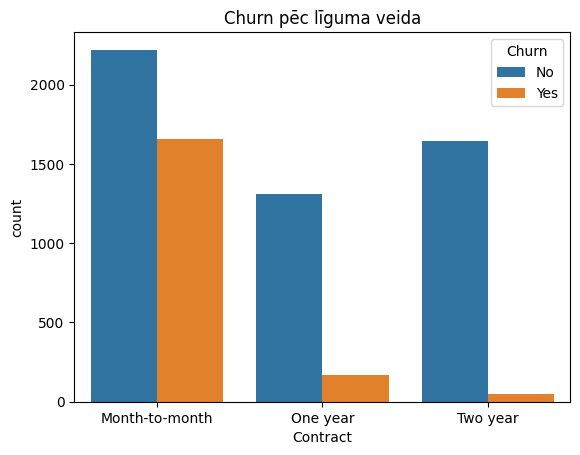

In [18]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn pēc līguma veida")
plt.show()

## Līguma veids un klientu aiziešana

Grafiks skaidri parāda, ka klienti ar **"Month-to-month"** līgumiem būtiski biežāk pamet uzņēmumu nekā klienti ar ilgtermiņa līgumiem.

Savukārt klienti ar **"One year"** un īpaši **"Two year"** līgumiem ir ievērojami stabilāki un reti aiziet.

Tas nozīmē, ka:
- īstermiņa līgumi rada augstāku churn risku
- ilgtermiņa līgumi būtiski samazina klientu aiziešanu

No biznesa skatpunkta:
- uzņēmumam vajadzētu aktīvi virzīt klientus uz ilgtermiņa līgumiem
- iespējams piedāvāt atlaides vai bonusus par 1–2 gadu līgumiem
- īpaša uzmanība jāpievērš klientiem ar "Month-to-month" līgumiem (retention kampaņas)

Šis ir viens no spēcīgākajiem indikatoriem churn prognozēšanā.

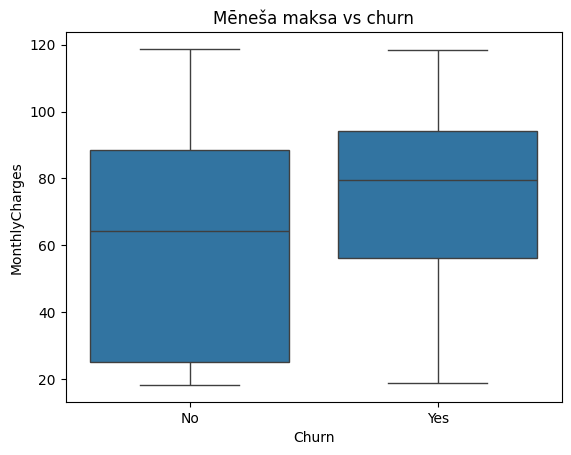

In [19]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Mēneša maksa vs churn")
plt.show()

## Mēneša maksas ietekme uz churn

Grafiks parāda, ka klientiem, kuri pamet uzņēmumu, vidēji ir nedaudz augstāka mēneša maksa.

Tomēr redzams, ka abu grupu (Churn = Yes un No) sadalījumi būtiski pārklājas.

Tas nozīmē, ka:
- cena ietekmē klientu aiziešanu
- bet tā nav vienīgais vai izšķirošais faktors

No biznesa skatpunkta:
- augstāka cena var palielināt churn risku
- taču svarīga ir arī klienta uztvertā vērtība (serviss, līgums, pakalpojums)

Secinājums:
cenu optimizācija viena pati neatrisinās churn problēmu — nepieciešama kombinēta pieeja.

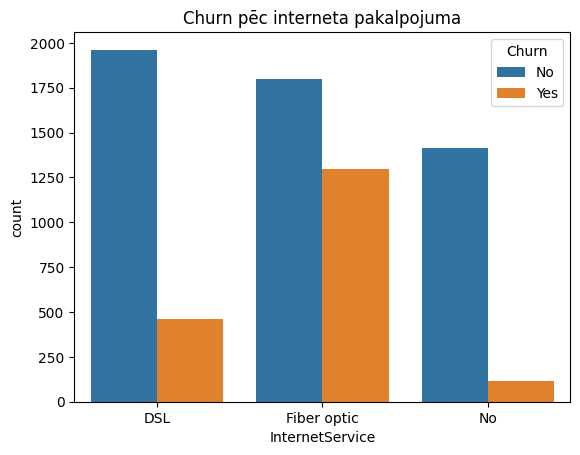

In [20]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn pēc interneta pakalpojuma")
plt.show()

## Interneta pakalpojuma ietekme uz churn

Grafiks parāda, ka klienti ar **Fiber optic** pakalpojumu pamet uzņēmumu biežāk nekā klienti ar DSL vai bez interneta.

Tomēr jāņem vērā, ka Fiber optic klientu skaits ir lielāks, tāpēc nepieciešama papildu analīze (procentos), lai izdarītu pilnīgi precīzus secinājumus.

Neskatoties uz to, redzams, ka:
- Fiber optic segmentā churn ir būtiska problēma
- DSL klienti ir stabilāki
- klienti bez interneta gandrīz neaiziet

No biznesa skatpunkta tas var norādīt uz:
- iespējamu cenu problēmu Fiber optic segmentā
- neatbilstību starp klienta gaidām un pakalpojuma kvalitāti
- konkurences spiedienu šajā segmentā

Šis segments ir labs kandidāts padziļinātai analīzei un churn samazināšanas iniciatīvām.

In [21]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


## Interneta pakalpojums un churn (procentu analīze)

Procentu analīze parāda būtiskas atšķirības starp klientu segmentiem:

- **Fiber optic** klientiem churn līmenis ir ~42%  
- **DSL** klientiem churn ir ~19%  
- klientiem bez interneta churn ir tikai ~7%

Tas nozīmē, ka:
- Fiber optic klienti aiziet **vairāk nekā 2x biežāk** nekā DSL klienti
- salīdzinot ar klientiem bez interneta, churn ir pat **~6x augstāks**

No biznesa skatpunkta tas ir kritisks signāls:

- Fiber optic segments ir **augsta riska zona**
- iespējama problēma ar cenu, kvalitāti vai klientu gaidām
- šis segments ir prioritāte churn samazināšanas iniciatīvām

Secinājums:
ne visi klienti ir vienādi — churn ir koncentrēts konkrētos segmentos, un tieši tur ir jāfokusē uzņēmuma resursi.

# B. Modelēšana

Šajā sadaļā dati tiek sagatavoti modelēšanai un izveidots mašīnmācīšanās modelis churn prognozēšanai.

Soļi:
- datu transformācija
- kategorisko datu kodēšana
- train/test sadalījums
- modeļa apmācība un novērtēšana

In [22]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [23]:
df_encoded = pd.get_dummies(df.drop("customerID", axis=1), drop_first=True)

In [24]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Datu sagatavošana modelēšanai

Lai sagatavotu datus mašīnmācīšanās modelim, tika veikti vairāki būtiski soļi.

Mērķa mainīgais (`Churn`) tika pārveidots uz bināru formu (1 – klients pamet uzņēmumu, 0 – paliek), lai modelis varētu veikt klasifikāciju.

Kategoriskie mainīgie tika pārveidoti skaitliskā formā, izmantojot one-hot encoding pieeju. Tas ļauj modelim analizēt kategorijas kā atsevišķas pazīmes.

Tāpat tika izņemta kolonna `customerID`, jo tā nesatur analītisku vērtību un varētu negatīvi ietekmēt modeli.

Dati tika sadalīti apmācības un testēšanas kopās (80% / 20%), lai objektīvi novērtētu modeļa veiktspēju uz neredzētiem datiem.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8239886444286728

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.70      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



## Modeļa rezultātu interpretācija

Modelis sasniedz aptuveni 82% precizitāti (accuracy), kas sākotnēji šķiet labs rezultāts.

Tomēr detalizētāka analīze parāda būtisku problēmu – modelis neefektīvi identificē klientus, kuri pamet uzņēmumu.

Churn klientiem (klase 1):
- recall ≈ 60% → modelis identificē tikai daļu no riska klientiem
- tas nozīmē, ka aptuveni 40% klientu, kuri aizies, netiek pamanīti

No biznesa skatpunkta tas ir kritiski:
- uzņēmums nevar reaģēt uz klientiem, kurus modelis neidentificē
- tiek zaudēti potenciālie ieņēmumi

Secinājums:
lai gan kopējā precizitāte ir laba, modelis nav pietiekami efektīvs churn noteikšanā un ir nepieciešami uzlabojumi.

In [27]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7750177430801988

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.77      0.83      1036
           1       0.55      0.79      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.78      0.79      1409



## Modeļa uzlabojuma rezultātu interpretācija

Pēc `class_weight="balanced"` pielietošanas modelis uzrāda izmaiņas:

- Accuracy samazinājās no ~82% uz ~78%
- Churn klientu recall pieauga no ~60% uz ~79%

Tas nozīmē, ka modelis tagad spēj identificēt būtiski lielāku daļu klientu, kuri pamet uzņēmumu.

No biznesa skatpunkta tas ir kritiski svarīgi:
- labāk identificēt riska klientus
- iespējams savlaicīgi reaģēt (piemēram, piedāvājumi, atlaides, retention kampaņas)

Trade-off:
- modelis kļūst mazāk precīzs kopumā
- bet daudz efektīvāks churn noteikšanā

Secinājums:
šis modelis ir praktiski vērtīgāks biznesam nekā iepriekšējais.

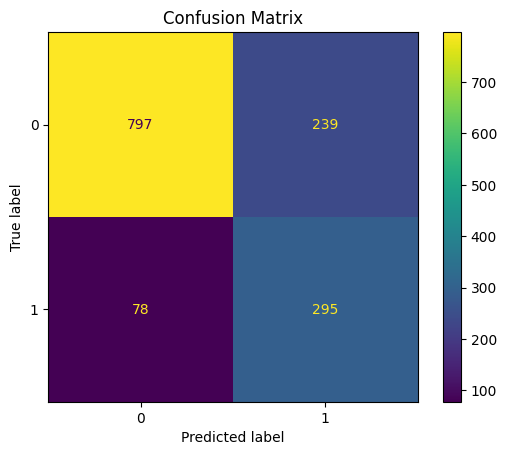

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

## Confusion Matrix interpretācija

Confusion matrix parāda modeļa prognožu kvalitāti:

- True Negative (797) – klienti pareizi identificēti kā lojāli
- True Positive (295) – klienti pareizi identificēti kā churn (pametuši)
- False Positive (239) – klienti kļūdaini uzskatīti par churn
- False Negative (78) – klienti palaisti garām (viskritiskākā kļūda)

Svarīgākais rādītājs šajā gadījumā ir False Negative skaits.

Modelis palaida garām tikai 78 churn klientus, bet veiksmīgi identificēja 295.

Tas nozīmē, ka modelis spēj atklāt lielāko daļu riska klientu un ļauj uzņēmumam savlaicīgi rīkoties.

No biznesa skatpunkta šis modelis ir efektīvs churn samazināšanai, jo prioritizē kritisko gadījumu identificēšanu.

# C. Biznesa secinājumi un ieteikumi

## Galvenie secinājumi

Analīze atklāj vairākus būtiskus faktorus, kas ietekmē klientu aiziešanu (churn):

1. **Līguma veids (Contract)**
   - Klienti ar *month-to-month* līgumiem pamet uzņēmumu ievērojami biežāk
   - Ilgtermiņa līgumi (1–2 gadi) būtiski samazina churn risku

2. **Interneta pakalpojuma veids (InternetService)**
   - Fiber optic klientiem ir augstāks churn līmenis nekā DSL
   - Tas var liecināt par cenu vai kvalitātes neatbilstību

3. **Mēneša maksa (MonthlyCharges)**
   - Klienti ar augstākām izmaksām biežāk pamet uzņēmumu
   - Cena ir viens no galvenajiem churn driveriem

4. **Modelēšanas rezultāti**
   - Modelis spēj identificēt ~79% churn klientu
   - Tas dod iespēju proaktīvi rīkoties un samazināt klientu aiziešanu

---

## Biznesa interpretācija

Churn nav nejaušs process — tas ir strukturēts un prognozējams.

Uzņēmums šobrīd:
- zaudē klientus, kurus varēja identificēt iepriekš
- maksā vairāk par jaunu klientu piesaisti nekā par esošo noturēšanu
- neizmanto savus datus pilnā potenciālā

---

## Konkrēti ieteikumi

### 1. Līgumu stratēģija
- Piedāvāt atlaides pārejai no *month-to-month* uz ilgtermiņa līgumiem
- Ieviest bonusus par lojalitāti (piemēram, zemāka cena pēc 6 mēnešiem)

---

### 2. Augsta riska klientu identificēšana
- Izmantot modeli, lai katru mēnesi identificētu churn risku
- Fokusēties uz klientiem ar:
  - augstu MonthlyCharges
  - month-to-month līgumiem
  - fiber optic pakalpojumu

---

### 3. Retention kampaņas
- Personalizēti piedāvājumi (atlaides, upgrade, papildu servisi)
- Proaktīva komunikācija (pirms klients pieņem lēmumu aiziet)

---

### 4. Cenu un vērtības optimizācija
- Pārskatīt fiber optic cenu struktūru
- Salīdzināt cenu vs uztverto vērtību klientu segmentā

---

## Potenciālais biznesa efekts

Pat neliels churn samazinājums var radīt būtisku finansiālo ietekmi:

- +5% klientu noturēšana var ievērojami palielināt peļņu
- Samazinās klientu piesaistes izmaksas (CAC)
- Palielinās klienta dzīves cikla vērtība (LTV)

---

## Noslēgums

Šis projekts parāda, ka:

- churn ir prognozējams
- dati var tikt izmantoti praktisku lēmumu pieņemšanai
- AI un analītika var tieši ietekmēt uzņēmuma rezultātus

Nākamais solis būtu:
→ integrēt šo modeli uzņēmuma operacionālajos procesos
→ automatizēt churn monitoringu un reakciju

Tas pārvērš analīzi par reālu biznesa instrumentu.